In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
#read the csv files
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

train_data.head()

,x1,x2,y
0,-0.925313,0.444987,0
1,4.518003,3.152296,1
2,-1.578006,0.093980,0
3,3.042269,3.095001,1
4,3.077301,1.664782,1


In [52]:
#split the csv files into X and y
x_train = train_data.drop('y', axis=1).values
y_train = train_data['y'].values

x_test = test_data.drop('y', axis=1).values
y_test = test_data['y'].values

In [53]:
#Use the GDA algorithm to fit the model
class GDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        #each class have a different mean vector
        self.means = np.zeros((len(self.classes), X.shape[1]))
        #each class have a different covariance matrix
        self.cov = np.zeros((X.shape[1], X.shape[1], len(self.classes)))
        # This is the prior probability of each class, which is the proportion of samples in each class
        self.priors = np.zeros(len(self.classes))
        
        for i, c in enumerate(self.classes):
            # Get the samples of class c
            X_c = X[y == c]

            self.means[i] = np.mean(X_c, axis=0)
            self.cov[:, :, i] = np.cov(X_c, rowvar=False)
            # Calculate the prior probability of class c as the proportion of samples in class c
            self.priors[i] = X_c.shape[0] / X.shape[0]
        
    
    def predict(self, X):
        # Calculate using bayes theorem the posterior probability of each class given the input X

        likelihoods = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            likelihoods[:, i] = self._multivariate_normal(X, self.means[i], self.cov[:, :, i]) * self.priors[i]

        # Return the class with the highest posterior probability
        return self.classes[np.argmax(likelihoods, axis=1)]

    def _multivariate_normal(self, X, mean, cov):
        # Implementation of the multivariate normal distribution
        return (1. / np.power(2 * np.pi, X.shape[1] / 2) * np.power(np.linalg.det(cov), 0.5)) * \
               np.exp(-0.5 * np.sum(np.dot(X - mean, np.linalg.inv(cov)) * (X - mean), axis=1))
        
        

In [54]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.show()

In [55]:
#Using the GDA algorithm to fit the model
model = GDA()
model.fit(x_train, y_train)
y_test_pred_gda = model.predict(x_test)

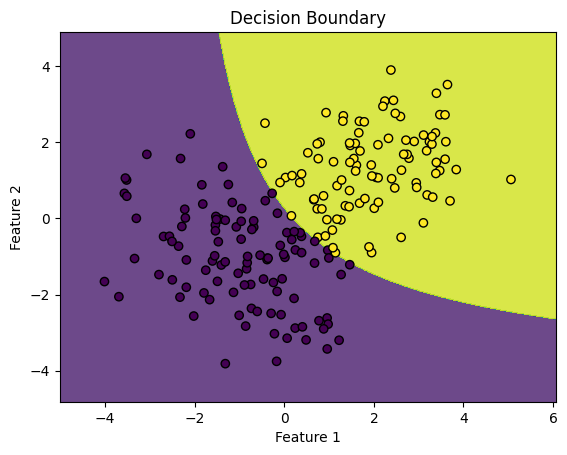

In [56]:
plot_decision_boundary(model, x_test, y_test_pred_gda)

In [57]:
#Use the LDA algorithm to fit the model
class LDA:
    def fit(self, X, y):
        self.classes = np.unique(y)
        #each class have a different mean vector
        self.means = np.zeros((len(self.classes), X.shape[1]))
        #each class have THE SAME covariance matrix
        self.cov = np.zeros((X.shape[1], X.shape[1]))
        # This is the prior probability of each class, which is the proportion of samples in each class
        self.priors = np.zeros(len(self.classes))
        
        for i, c in enumerate(self.classes):
            # Get the samples of class c
            X_c = X[y == c]

            self.means[i] = np.mean(X_c, axis=0)
            self.cov += (X_c.shape[0] - 1) * np.cov(X_c, rowvar=False)
            # Calculate the prior probability of class c as the proportion of samples in class c
            self.priors[i] = X_c.shape[0] / X.shape[0]

        self.cov /= X.shape[0] - len(self.classes)
        
    
    def predict(self, X):
        # Calculate using bayes theorem the posterior probability of each class given the input X

        likelihoods = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            likelihoods[:, i] = self._multivariate_normal(X, self.means[i], self.cov) * self.priors[i]

        # Return the class with the highest posterior probability
        return self.classes[np.argmax(likelihoods, axis=1)]

    def _multivariate_normal(self, X, mean, cov):
        # Implementation of the multivariate normal distribution
        return (1. / np.power(2 * np.pi, X.shape[1] / 2) * np.power(np.linalg.det(cov), 0.5)) * \
               np.exp(-0.5 * np.sum(np.dot(X - mean, np.linalg.inv(cov)) * (X - mean), axis=1))
        
        

In [59]:
model = LDA()
model.fit(x_train, y_train)
y_test_pred_lda = model.predict(x_test)

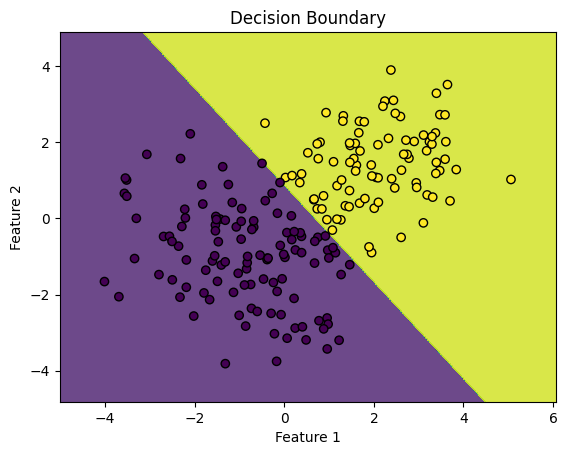

In [60]:
plot_decision_boundary(model, x_test, y_test_pred_lda)

In [ ]:
#save results to csv file
gda_results = pd.DataFrame({'x_test': x_test[:, 0], 'y_test': y_test, 'y_test_pred': y_test_pred_gda})
gda_results.to_csv('gda_predictions.csv', index=False)

lda_results = pd.DataFrame({'x_test': x_test[:, 0], 'y_test': y_test, 'y_test_pred': y_test_pred_lda})
lda_results.to_csv('lda_predictions.csv', index=False)  